E3-sym-fixed-explicit: Corridor navigation with explicit fixed symmetric drift schedules

This notebook returns to the setting where the drift schedule $\sigma_k$ is **given** rather than optimized.

We compare three cases, always optimizing only the guide $\nu_k$ and the anisotropic confinement $\beta_k$, with the **same baseline initialization** in all three runs:

1. **Reference:** $\sigma_k = 0$.
2. **Case #1:** a fixed explicit smooth symmetric schedule
   $$
   \sigma(t)=\alpha\sin^4(\pi t)
   \begin{pmatrix}
   \mu+\delta\cos(2\pi t) & \beta\sin(2\pi t)\\
   \beta\sin(2\pi t) & \mu-\delta\cos(2\pi t)
   \end{pmatrix},
   $$
   sampled at the PWC interval midpoints.
3. **Case #2:** the negative of Case #1.

For each case we monitor:
- analytic corridor loss,
- analytic control effort,
- analytic stiffness,
- EM diagnostics, including the empirical split between terminal modes.



In [1]:
from __future__ import annotations

import math
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import torch

if "__file__" in globals():
    ROOT = Path(__file__).resolve().parents[1]
else:
    ROOT = Path.cwd().resolve()
    if not (ROOT / "lqgm_pid").exists():
        for parent in [ROOT] + list(ROOT.parents):
            if (parent / "lqgm_pid").exists():
                ROOT = parent
                break

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.common import (
    ensure_dir,
    set_seed,
    default_device,
    default_dtype,
    save_metrics_json,
)
from lqgm_pid import (
    GaussianMixture, MatrixPWCProtocol, TimeDomain, LQGMPID,
    gmm_control, backward_sweep, forward_sweep,
)
from lqgm_pid.density import exact_marginal_gmm
from lqgm_pid.control import eval_bwd, eval_fwd

# Force reload to pick up the factored C propagator fix.
# Necessary if the kernel was started before the file was updated.
import importlib
import lqgm_pid.hamiltonian;  importlib.reload(lqgm_pid.hamiltonian)
import lqgm_pid.coeff_propagator; importlib.reload(lqgm_pid.coeff_propagator)
import lqgm_pid.sweep; importlib.reload(lqgm_pid.sweep)
import lqgm_pid.control; importlib.reload(lqgm_pid.control)
import lqgm_pid.density; importlib.reload(lqgm_pid.density)
# Re-import after reload
from lqgm_pid.sweep import backward_sweep, forward_sweep
from lqgm_pid.control import gmm_control, eval_bwd, eval_fwd
from lqgm_pid.density import exact_marginal_gmm
print("Reloaded all lqgm_pid modules")

Reloaded all lqgm_pid modules


## Configuration

All corridor/target geometry is **identical to E1**.  The new parameters
control the initial GMM (entrance positions and widths).



In [2]:
SEED = 42
DEVICE = default_device()
DTYPE = default_dtype()

OUTDIR = ensure_dir(str(ROOT / "results" / "E3_symsigma_fixedcases"))
FIGDIR = ensure_dir(str(ROOT / "figs"))

# Protocol
K = 10
BC_EPS = 1e-6
TD_EPS = 1e-3

# Optimization
N_ITERS = 300
LR = 3e-2
PRINT_EVERY = 20

# Corridor window
T_CORR_STAR = 0.80

# Weights (same as E1)
LAMBDA_CORR = 10.0
LAMBDA_RHO = 0.10
LAMBDA_BETA = 0.05

# Corridor geometry (same as E1)
SWING_AMPLITUDE = 0.70
SWING_KAPPA = 6.0

# Stiffnesses (same as E1)
BETA_LONG_FIXED = 0.2
BETA_PERP_INIT = 15.0
BETA_PERP_MIN = 2.0
BETA_PERP_MAX = 60.0
BETA_PERP_BASELINE = 3.0

# Gaussian corridor kernel (same as E1)
OMEGA_LONG = 0.80
OMEGA_PERP = 0.20

# --- NEW: initial GMM parameters ---
X_ENTRY = -0.3          # longitudinal position of entrance ports
DELTA_Y = 0.50          # transverse half-separation between entrance modes
SIGMA_0 = 0.12          # initial mode standard deviation (isotropic)
B_INIT = 60             # number of particles sampled from initial GMM (fixed once)

# EM simulation for scatter plots
N_STEPS_EM = 200        # Euler–Maruyama time steps
B_SIM = 400             # total EM particles

# Fixed-sigma study diagnostics
B_STIFF = 12
B_CONTROL = 12

# Explicit symmetric fixed-sigma profile
SIGMA_FIXED_SCALE = 0.05
SIGMA_FIXED_MU = 1.0
SIGMA_FIXED_DELTA = 0.5
SIGMA_FIXED_BETA = 0.4
SIGMA_FIXED_ENVELOPE_POWER = 4.0

# Snapshot times
SNAPSHOT_TIMES = [0.00, 0.12, 0.25, 0.38, 0.50, 0.62, 0.75, 0.88, 1.00]
MERGE_TIMES = [0.00, 0.04, 0.08, 0.12, 0.16, 0.20, 0.25]

# Visualization
XLIM = (-1.0, 4.0)
YLIM = (-1.6, 1.6)
NGRID_DENSITY = 120
NGRID_SCORE = 18

set_seed(SEED)
print(f"Device: {DEVICE}")
print(f"Output directory: {OUTDIR}")

Device: cpu
Output directory: /Users/chertkov/Dropbox/Apps/Overleaf/LQ-GM-PID/guided-plus/results/E3_symsigma_fixedcases


## Geometry helpers (identical to E1)



In [3]:
def _normalize_rows(x, eps=1e-12):
    return x / torch.linalg.norm(x, dim=-1, keepdim=True).clamp_min(eps)

def _fd_tangent(xy):
    dx = torch.zeros_like(xy)
    dx[1:-1] = 0.5 * (xy[2:] - xy[:-2])
    dx[0] = xy[1] - xy[0]
    dx[-1] = xy[-1] - xy[-2]
    return _normalize_rows(dx)

def _match_to_grid(query_t, grid_t):
    return torch.argmin(torch.abs(query_t.unsqueeze(-1) - grid_t.unsqueeze(0)), dim=-1)

## Corridor midline (identical to E1)



In [4]:
def _normalize_rows(x, eps=1e-12):
    return x / torch.linalg.norm(x, dim=-1, keepdim=True).clamp_min(eps)

def _fd_tangent(xy):
    dx = torch.zeros_like(xy)
    dx[1:-1] = 0.5 * (xy[2:] - xy[:-2])
    dx[0] = xy[1] - xy[0]
    dx[-1] = xy[-1] - xy[-2]
    return _normalize_rows(dx)

def _match_to_grid(query_t, grid_t):
    return torch.argmin(torch.abs(query_t.unsqueeze(-1) - grid_t.unsqueeze(0)), dim=-1)

def make_s_corridor(s_grid, *, x_end=3.0, A=SWING_AMPLITUDE, kappa=SWING_KAPPA):
    s = s_grid
    x = x_end * s
    y = A * torch.tanh(kappa * (s - 0.30)) - A * torch.tanh(kappa * (s - 0.70))
    y = y - y[0] - (y[-1] - y[0]) * s
    xy = torch.stack([x, y], dim=-1)
    tangent = _fd_tangent(xy)
    normal = torch.stack([-tangent[:, 1], tangent[:, 0]], dim=-1)
    return {"s": s, "xy": xy, "tangent": tangent, "normal": normal}

def sample_corridor_at(corridor, s_k):
    idx = _match_to_grid(s_k, corridor["s"])
    return {k: corridor[k][idx] for k in ["xy", "tangent", "normal"]}

## Target GMM (identical to E1)



In [5]:
def make_target(dtype=DTYPE, device=DEVICE):
    weights = torch.tensor([0.5, 0.5], dtype=dtype, device=device)
    means = torch.tensor([[3.0, 0.50], [3.0, -0.50]], dtype=dtype, device=device)
    cov = torch.tensor([[0.06, 0.00], [0.00, 0.05]], dtype=dtype, device=device)
    covs = torch.stack([cov, cov], dim=0)
    return GaussianMixture(weights=weights, means=means, covs=covs)

## Initial GMM

Two entrance modes placed symmetrically above and below the corridor axis,
slightly behind the corridor entry point:
$$p^{(\mathrm{in})}(x) = \tfrac{1}{2}\,\mathcal{N}\bigl(x;\,(x_{\mathrm{entry}},+\delta_y),\,\sigma_0^2 I\bigr) + \tfrac{1}{2}\,\mathcal{N}\bigl(x;\,(x_{\mathrm{entry}},-\delta_y),\,\sigma_0^2 I\bigr).$$



In [6]:
def make_initial_gmm(dtype=DTYPE, device=DEVICE):
    weights = torch.tensor([0.5, 0.5], dtype=dtype, device=device)
    means = torch.tensor([
        [X_ENTRY,  DELTA_Y],
        [X_ENTRY, -DELTA_Y],
    ], dtype=dtype, device=device)
    cov = SIGMA_0**2 * torch.eye(2, dtype=dtype, device=device)
    covs = torch.stack([cov, cov], dim=0)
    return GaussianMixture(weights=weights, means=means, covs=covs)

## Protocol builders (identical to E1)



In [7]:
def make_breaks(K, dtype=DTYPE, device=DEVICE):
    return torch.linspace(0.0, 1.0, K + 1, dtype=dtype, device=device)

def s_midpoints(K, dtype=DTYPE, device=DEVICE):
    breaks = make_breaks(K, dtype=dtype, device=device)
    return 0.5 * (breaks[:-1] + breaks[1:])

def _make_sigma_zero_legacy(K, dtype=DTYPE, device=DEVICE):
    """Legacy zero-drift helper kept only so the pre-general-E3 cells compile.

    The actual rotational/general-E3 experiment below overrides protocol
    construction and supplies sigma explicitly through the general-E3 inner loop.
    """
    return torch.zeros(K, 2, 2, dtype=dtype, device=device)


def build_baseline_protocol(corridor, s_k, breaks):
    geom = sample_corridor_at(corridor, s_k)
    K = s_k.numel()
    nu = geom["xy"].clone()
    beta = BETA_PERP_BASELINE * torch.eye(2, dtype=DTYPE, device=DEVICE).unsqueeze(0).expand(K, -1, -1).clone()
    sigma = _make_sigma_zero_legacy(K)
    protocol = MatrixPWCProtocol(breaks=breaks, sigma=sigma, beta=beta, nu=nu,
                                  time_domain=TimeDomain(eps=TD_EPS))
    return protocol, {"nu": nu, "m": geom["xy"], **geom}

## Trainable protocol state (identical to E1)

- $\rho_k$: transverse guide offset from corridor midline.
- $c_k$: unconstrained parameter, mapped to $\beta_k^{(\perp)} \in [\beta_{\min}, \beta_{\max}]$ via sigmoid.



In [8]:
@dataclass
class TrainableState:
    rho: torch.nn.Parameter
    c_beta: torch.nn.Parameter

def c_beta_to_beta_perp(c):
    return BETA_PERP_MIN + (BETA_PERP_MAX - BETA_PERP_MIN) * torch.sigmoid(c)

def beta_perp_to_c_beta(bp):
    s = (bp - BETA_PERP_MIN) / (BETA_PERP_MAX - BETA_PERP_MIN)
    s = max(1e-6, min(1.0 - 1e-6, s))
    return math.log(s / (1.0 - s))

def build_trainable_protocol(state, corridor, s_k, breaks):
    geom = sample_corridor_at(corridor, s_k)
    tangent, normal, m_k = geom["tangent"], geom["normal"], geom["xy"]
    K = s_k.numel()
    nu = m_k + state.rho[:, None] * normal
    beta_list = []
    sigma = _make_sigma_zero_legacy(K)
    b_long = torch.tensor(BETA_LONG_FIXED, dtype=DTYPE, device=DEVICE)
    for k in range(K):
        R = torch.stack([tangent[k], normal[k]], dim=-1)
        b_perp = c_beta_to_beta_perp(state.c_beta[k])
        D = torch.diag(torch.stack([b_long, b_perp]))
        beta_list.append(R @ D @ R.T)
    beta = torch.stack(beta_list)
    protocol = MatrixPWCProtocol(breaks=breaks, sigma=sigma, beta=beta, nu=nu,
                                  time_domain=TimeDomain(eps=TD_EPS))
    aux = {"nu": nu, "m": m_k, "tangent": tangent, "normal": normal, "beta": beta}
    return protocol, aux

## Exact conditional marginal for sampled initial particles

Given $B$ particles $\{x_0^{(n)}\}_{n=1}^B$ sampled from $p^{(\mathrm{in})}$,
the approximate marginal at time $t$ is

$$p_t(x) \approx \frac{1}{B}\sum_{n=1}^B p_t^*(x \mid x_0^{(n)}),$$

where each $p_t^*(x \mid x_0^{(n)})$ is an $M_{\mathrm{tar}}$-component GMM
computed via the standard ratio-form formulas.  This gives a
$B \times M_{\mathrm{tar}}$-component GMM with uniform weights $1/B$.

### Efficient computation

The quadratic coefficients $(A_t^\pm, B_t^\pm, C_t^-, S_k, \Lambda_k,
\Pi_k, \Sigma_k)$ are **independent of $x_0$** and computed once (using the
standard delta-BC forward sweep).  For each particle $x_0^{(n)}$, only two
matrix-vector products are needed: $B_1^+ x_0^{(n)}$ and $B_t^+ x_0^{(n)}$.

### Corridor loss

The alignment is a **particle average** of per-particle closed-form scores:

$$\mathcal{A}_k \approx \frac{1}{B}\sum_{n=1}^B
  \sum_{m=1}^{M_{\mathrm{tar}}} \bar\pi_m^{(n)}(t_k)\,
  \mathcal{A}_k^{(n,m)}.$$



In [9]:
def _shared_marginal_quantities(protocol, target, t, bwd, fwd):
    """Precompute x0-independent quantities for the marginal at time t."""
    dev = protocol.device
    dty = protocol.dtype
    Mtar = target.M
    d = protocol.d

    cs_bwd = eval_bwd(t, bwd, protocol)
    cs_fwd_t = eval_fwd(t, fwd, protocol)
    cs_fwd1 = fwd[protocol.K]

    A_m = cs_bwd.A;  B_m = cs_bwd.B;  C_m = cs_bwd.C
    tx_m = cs_bwd.theta_x;  ty_m = cs_bwd.theta_y
    A_p = cs_fwd_t.A;  B_p = cs_fwd_t.B;  tx_p = cs_fwd_t.theta_x
    A1_p = cs_fwd1.A;  B1_p = cs_fwd1.B;  tx1_p = cs_fwd1.theta_x

    Ps = target.precisions.to(dev, dty)
    ms = target.means.to(dev, dty)
    logpi_tar = torch.log(target.weights.to(dev, dty))

    Sk = C_m.unsqueeze(0) + Ps - A1_p.unsqueeze(0)
    Sk_inv = torch.linalg.inv(Sk)
    Pkm = torch.bmm(Ps, ms.unsqueeze(-1)).squeeze(-1)
    Bm_exp = B_m.unsqueeze(0).expand(Mtar, d, d)
    BSkInv = torch.bmm(Bm_exp, Sk_inv)
    Lambda = A_m.unsqueeze(0) - torch.bmm(BSkInv, Bm_exp.transpose(-2, -1))
    Pi = A_p.unsqueeze(0) + Lambda
    Sigma = torch.linalg.inv(Pi)

    logdet_Sk = torch.logdet(Sk)
    logdet_Pk = torch.logdet(Ps)
    logdet_Pi = torch.logdet(Pi)
    mPkm = torch.einsum('md,md->m', ms, Pkm)

    return {
        "B1_p": B1_p, "tx1_p": tx1_p, "B_p": B_p, "tx_p": tx_p,
        "tx_m": tx_m, "ty_m": ty_m,
        "Sk_inv": Sk_inv, "BSkInv": BSkInv, "Pkm": Pkm,
        "Pi": Pi, "Sigma": Sigma,
        "logpi_tar": logpi_tar, "logdet_Sk": logdet_Sk,
        "logdet_Pk": logdet_Pk, "logdet_Pi": logdet_Pi, "mPkm": mPkm,
    }


def _conditional_marginal_for_x0(x0, shared):
    """Compute the M_tar-component conditional marginal for a single x0.

    Returns (logw, mu, Sigma):
      logw  : (Mtar,)       unnormalized log-weights
      mu    : (Mtar, d)     component means
      Sigma : (Mtar, d, d)  component covariances (x0-independent)
    """
    S = shared
    B1p_x0 = S["B1_p"] @ x0
    qk = S["ty_m"].unsqueeze(0) + S["Pkm"] - B1p_x0.unsqueeze(0) - S["tx1_p"].unsqueeze(0)
    BSkInv_q = torch.bmm(S["BSkInv"], qk.unsqueeze(-1)).squeeze(-1)
    lam_k = S["tx_m"].unsqueeze(0) + BSkInv_q

    Bp_x0 = S["B_p"] @ x0
    rhs = (Bp_x0 + S["tx_p"]).unsqueeze(0) + lam_k
    mu = torch.bmm(S["Sigma"], rhs.unsqueeze(-1)).squeeze(-1)

    Skinv_qk = torch.bmm(S["Sk_inv"], qk.unsqueeze(-1)).squeeze(-1)
    qSinvq = torch.einsum('md,md->m', qk, Skinv_qk)
    Ck = -0.5*S["logdet_Sk"] + 0.5*S["logdet_Pk"] - 0.5*S["mPkm"] + 0.5*qSinvq
    muPimu = torch.einsum('md,md->m', mu, torch.bmm(S["Pi"], mu.unsqueeze(-1)).squeeze(-1))
    logw = S["logpi_tar"] + Ck - 0.5*S["logdet_Pi"] + 0.5*muPimu

    return logw, mu, S["Sigma"]


def marginal_from_samples(
    protocol: MatrixPWCProtocol,
    target: GaussianMixture,
    x0_samples: torch.Tensor,   # (B, d)
    t: float,
    *,
    bc_eps: float = BC_EPS,
    _cache: Optional[Dict] = None,
) -> Dict[str, torch.Tensor]:
    """Assemble the B*M_tar component marginal for plotting.

    Each particle contributes M_tar components with weight 1/B.
    """
    B_samp = x0_samples.shape[0]

    if _cache is not None and "bwd" in _cache:
        bwd, fwd = _cache["bwd"], _cache["fwd"]
    else:
        bwd = backward_sweep(protocol, bc_eps=bc_eps)
        fwd = forward_sweep(protocol, bc_eps=bc_eps)  # standard delta BC
        if _cache is not None:
            _cache["bwd"] = bwd; _cache["fwd"] = fwd

    shared = _shared_marginal_quantities(protocol, target, t, bwd, fwd)

    all_logw, all_mu, all_cov = [], [], []
    log_B = math.log(B_samp)

    for n in range(B_samp):
        logw_n, mu_n, Sigma_n = _conditional_marginal_for_x0(x0_samples[n], shared)
        all_logw.append(logw_n - log_B)
        all_mu.append(mu_n)
        all_cov.append(Sigma_n)

    logw_all = torch.cat(all_logw)
    logw_all = logw_all - torch.logsumexp(logw_all, dim=0)
    return {
        "weights": torch.exp(logw_all),
        "means": torch.cat(all_mu, dim=0),
        "covs": torch.cat(all_cov, dim=0),
    }

## Corridor loss and regularization

The corridor loss averages the per-particle alignment over the $B$ sampled
initial particles.  For each particle $x_0^{(n)}$ and time $t_k$, the
alignment is a closed-form sum over $M_{\mathrm{tar}}$ Gaussians.
**No Euler–Maruyama is involved.**



In [10]:
def make_kernel_matrix(tangent, normal, omega_long, omega_perp):
    Q = torch.stack([tangent, normal], dim=-1)
    W_inv_sq = torch.diag(torch.tensor(
        [1.0 / omega_long**2, 1.0 / omega_perp**2], dtype=DTYPE, device=DEVICE))
    return Q @ W_inv_sq @ Q.T

def kernel_alignment_single(mu, Sigma, nu, A):
    d = mu.numel()
    I = torch.eye(d, dtype=mu.dtype, device=mu.device)
    M = I + Sigma @ A
    delta = mu - nu
    return torch.exp(-0.5 * delta @ (A @ torch.linalg.solve(M, delta))) / torch.sqrt(torch.det(M))

def exact_alignment(marginal, center, tangent, normal):
    A = make_kernel_matrix(tangent, normal, OMEGA_LONG, OMEGA_PERP)
    w = marginal["weights"]
    return sum(w[k] * kernel_alignment_single(marginal["means"][k], marginal["covs"][k], center, A)
               for k in range(w.numel()))

def density_corridor_loss(protocol, target, x0_samples, aux, s_k, *, t_star):
    """Corridor loss: particle-averaged alignment with corridor midline.

    For each time t_k in the corridor window, we compute alignment for every
    particle x0^(n) (using the exact conditional marginal) and average.
    """
    mask = s_k <= t_star
    bwd = backward_sweep(protocol, bc_eps=BC_EPS)
    fwd = forward_sweep(protocol, bc_eps=BC_EPS)
    B_samp = x0_samples.shape[0]
    vals = []
    for j in torch.where(mask)[0].tolist():
        t_q = float(s_k[j].item())
        shared = _shared_marginal_quantities(protocol, target, t_q, bwd, fwd)
        A_corr = make_kernel_matrix(aux["tangent"][j], aux["normal"][j], OMEGA_LONG, OMEGA_PERP)
        center = aux["m"][j]
        align_sum = torch.zeros((), dtype=DTYPE, device=protocol.device)
        for n in range(B_samp):
            logw_n, mu_n, Sigma_n = _conditional_marginal_for_x0(x0_samples[n], shared)
            w_n = torch.softmax(logw_n, dim=0)
            a_n = sum(w_n[m] * kernel_alignment_single(mu_n[m], Sigma_n[m], center, A_corr)
                      for m in range(w_n.numel()))
            align_sum = align_sum + a_n
        vals.append(1.0 - align_sum / B_samp)
    return torch.stack(vals).mean()

def rho_regularization(rho, *, alpha_barrier=0.55):
    smooth = ((rho[1:] - rho[:-1])**2).mean()
    if rho.numel() >= 3:
        smooth = smooth + 0.5 * ((rho[2:] - 2*rho[1:-1] + rho[:-2])**2).mean()
    barrier = torch.nn.functional.softplus(15.0 * (rho.abs() - alpha_barrier)).mean() / 15.0
    return smooth + 0.3 * barrier

def beta_regularization(c_beta, c_beta0):
    smooth = ((c_beta[1:] - c_beta[:-1])**2).mean()
    anchor = ((c_beta - c_beta0)**2).mean()
    return smooth + 0.5 * anchor

def total_loss(protocol, target, x0_samples, state, aux, s_k, c_beta0):
    Lc = density_corridor_loss(protocol, target, x0_samples, aux, s_k, t_star=T_CORR_STAR)
    Lr = rho_regularization(state.rho)
    Lb = beta_regularization(state.c_beta, c_beta0)
    L = LAMBDA_CORR * Lc + LAMBDA_RHO * Lr + LAMBDA_BETA * Lb
    return L, {"Ltotal": L.item(), "Lcorr": Lc.item(), "Lrho": Lr.item(), "Lbeta": Lb.item()}

## Visualization helpers (same as E1, adapted for distributed initial)



In [11]:
def eval_gmm_density(weights, means, covs, xgrid, ygrid):
    weights = weights.detach()
    means = means.detach()
    covs = covs.detach()
    nx, ny = xgrid.shape[1], xgrid.shape[0]
    pts = torch.stack([
        torch.as_tensor(xgrid, dtype=DTYPE).reshape(-1),
        torch.as_tensor(ygrid, dtype=DTYPE).reshape(-1),
    ], dim=-1)
    log_p = torch.full((pts.shape[0],), -1e30, dtype=DTYPE)
    for k in range(weights.numel()):
        diff = pts - means[k].unsqueeze(0)
        L = torch.linalg.cholesky(covs[k])
        z = torch.linalg.solve_triangular(L, diff.T, upper=False).T
        log_comp = -0.5 * (z**2).sum(-1) - L.diagonal().log().sum() - math.log(2*math.pi)
        log_wk = math.log(max(weights[k].item(), 1e-30)) + log_comp
        log_p = torch.logaddexp(log_p, log_wk)
    return torch.exp(log_p).reshape(ny, nx).numpy()


def eval_score_field_distributed(protocol, target, x0_samples, t, xgrid, ygrid):
    """Evaluate the particle-averaged drift field on a meshgrid.

    Uses the standard delta-BC forward sweep (matching the density computation).
    """
    dev = protocol.device
    dty = protocol.dtype
    nx, ny = xgrid.shape[1], xgrid.shape[0]
    pts = torch.stack([
        torch.as_tensor(xgrid, dtype=DTYPE, device=dev).reshape(-1),
        torch.as_tensor(ygrid, dtype=DTYPE, device=dev).reshape(-1),
    ], dim=-1)

    bwd = backward_sweep(protocol, bc_eps=BC_EPS)
    fwd = forward_sweep(protocol, bc_eps=BC_EPS)  # standard delta BC

    u_avg = torch.zeros_like(pts)
    B_samp = x0_samples.shape[0]
    for n in range(B_samp):
        u_n, _, _ = gmm_control(t, pts, x0_samples[n], bwd, fwd, target, protocol)
        u_avg = u_avg + u_n
    u_avg = u_avg / B_samp

    ux = u_avg[:, 0].reshape(ny, nx).numpy()
    uy = u_avg[:, 1].reshape(ny, nx).numpy()
    return ux, uy


def sample_from_marginal(marginal, n_samples, seed=0):
    w = marginal["weights"].detach().cpu()
    mus = marginal["means"].detach().cpu()
    covs = marginal["covs"].detach().cpu()
    gen = torch.Generator().manual_seed(seed)
    ids = torch.multinomial(w, n_samples, replacement=True, generator=gen)
    out = torch.empty(n_samples, mus.shape[1], dtype=DTYPE)
    for k in range(w.numel()):
        idx = torch.where(ids == k)[0]
        if idx.numel() == 0:
            continue
        L = torch.linalg.cholesky(covs[k])
        z = torch.randn(idx.numel(), mus.shape[1], generator=gen, dtype=DTYPE)
        out[idx] = mus[k] + z @ L.T
    return out

## Vectorized control with per-particle $x_0$

The control $u^*(t, x; x_0) = \sum_k \rho_k(t,x;x_0)\,(-\Lambda_k x + \lambda_k(x_0))$
depends on $x_0$ only through the linear term $q_k = \theta_y^- + P_k m_k - B_1^+ x_0 - \theta_{x;1}^+$.

The $x_0$-independent quantities ($\Lambda_k, S_k^{-1}, B^- S_k^{-1}$, etc.)
are computed once per time step.  The $x_0$-dependent parts ($q_k, \lambda_k, C_k$)
are simple matrix-vector products that vectorize over $B$ particles.

This gives the **exact per-particle control** with the same cost as the
mode-center batched version: $O(B \times M \times d^2)$ per step.



In [12]:
def _batched_control_multi_x0(
    t: float,
    x: torch.Tensor,       # (B, d)
    x0_all: torch.Tensor,  # (B, d)
    bwd, fwd, target, protocol,
) -> torch.Tensor:
    """Evaluate u*(t, x_n; x0_n) for all n simultaneously.

    Each particle n gets the control conditioned on its own x0_n.
    Fully vectorized — no Python loop over particles.

    Returns u : (B, d)
    """
    dev = protocol.device
    dty = protocol.dtype
    Mtar = target.M
    d = protocol.d
    B = x.shape[0]

    # Evaluate sweep coefficients at time t (shared across all particles)
    cs_bwd = eval_bwd(t, bwd, protocol)
    cs_fwd_t = eval_fwd(t, fwd, protocol)
    cs_fwd1 = fwd[protocol.K]

    A_m = cs_bwd.A;  B_m = cs_bwd.B;  C_m = cs_bwd.C
    tx_m = cs_bwd.theta_x;  ty_m = cs_bwd.theta_y
    A1_p = cs_fwd1.A;  B1_p = cs_fwd1.B;  tx1_p = cs_fwd1.theta_x

    Ps = target.precisions.to(dev, dty)    # (M, d, d)
    ms = target.means.to(dev, dty)         # (M, d)
    logpi = torch.log(target.weights.to(dev, dty))  # (M,)

    # --- x0-independent quantities (computed once) ---
    Sk = C_m.unsqueeze(0) + Ps - A1_p.unsqueeze(0)            # (M, d, d)
    Sk_inv = torch.linalg.inv(Sk)                              # (M, d, d)
    Pkm = torch.bmm(Ps, ms.unsqueeze(-1)).squeeze(-1)          # (M, d)
    Bm_exp = B_m.unsqueeze(0).expand(Mtar, d, d)               # (M, d, d)
    BSkInv = torch.bmm(Bm_exp, Sk_inv)                         # (M, d, d)
    Lambda = A_m.unsqueeze(0) - torch.bmm(BSkInv, Bm_exp.transpose(-2, -1))  # (M, d, d)

    logdet_Sk = torch.logdet(Sk)              # (M,)
    logdet_Pk = torch.logdet(Ps)              # (M,)
    mPkm = torch.einsum('md,md->m', ms, Pkm)  # (M,)

    # --- x0-dependent quantities (vectorized over B) ---
    # q_k = ty_m + Pkm - B1_p x0 - tx1_p       (B, M, d)
    qk_base = ty_m.unsqueeze(0) + Pkm - tx1_p.unsqueeze(0)    # (M, d)
    B1p_x0 = x0_all @ B1_p.T                                   # (B, d)
    qk = qk_base.unsqueeze(0) - B1p_x0.unsqueeze(1)            # (B, M, d)

    # λ_k = tx_m + BSkInv @ q_k                (B, M, d)
    BSkInv_q = torch.einsum('mij,bmj->bmi', BSkInv, qk)        # (B, M, d)
    lam_k = tx_m.unsqueeze(0).unsqueeze(0) + BSkInv_q           # (B, M, d)

    # C_k = -½ log|Sk| + ½ log|Pk| - ½ m^T Pk m + ½ q^T Sk^{-1} q
    Skinv_q = torch.einsum('mij,bmj->bmi', Sk_inv, qk)         # (B, M, d)
    qSinvq = torch.einsum('bmd,bmd->bm', qk, Skinv_q)          # (B, M)
    Ck = (-0.5*logdet_Sk + 0.5*logdet_Pk - 0.5*mPkm).unsqueeze(0) + 0.5*qSinvq  # (B, M)

    # --- Control at (x_n, x0_n) ---
    # Λ_k x_n  for each (n, k)
    Lam_x = torch.einsum('mij,bj->bmi', Lambda, x)              # (B, M, d)
    # log w_k = log π_k + C_k - ½ x^T Λ_k x + λ_k^T x
    xLx = torch.einsum('bd,bmd->bm', x, Lam_x)                 # (B, M)
    lam_x = torch.einsum('bmd,bd->bm', lam_k, x)               # (B, M)
    log_w = logpi.unsqueeze(0) + Ck - 0.5*xLx + lam_x           # (B, M)

    # Responsibilities and control
    rho = torch.softmax(log_w, dim=-1)                           # (B, M)
    neg_Lam_x_plus_lam = -Lam_x + lam_k                         # (B, M, d)
    u = torch.einsum('bm,bmd->bd', rho, neg_Lam_x_plus_lam)     # (B, d)

    return u

## Euler-Maruyama simulation with per-particle $x_0$

Each particle uses its **own** $x_0^{(n)}$ for the control — not the mode
center.  This is essential for nonzero $\sigma$: the shear amplifies
initial position differences through $q_k = \ldots - B_1^+ x_0$, and
using the wrong $x_0$ flips the terminal responsibilities.

$$x_{t+\Delta t}^{(n)} = x_t^{(n)} + \bigl(\sigma_k\, x_t^{(n)} + u^*(t, x_t^{(n)};\, x_0^{(n)})\bigr)\,\Delta t + \sqrt{\Delta t}\,\xi_t^{(n)}$$

The control is evaluated via `_batched_control_multi_x0`, which vectorizes
over all $B$ particles simultaneously — same cost as the mode-center version.



In [13]:
@torch.no_grad()
def simulate_distributed(
    protocol, target, x0_particles, initial_gmm, *,
    n_steps=N_STEPS_EM, seed=SEED,
):
    """EM simulation with per-particle x0 and protocol sigma.

    Parameters
    ----------
    x0_particles : (B, d) starting positions
    initial_gmm  : unused, kept for API compatibility

    Returns
    -------
    times : (n_steps+1,) tensor
    traj  : (n_steps+1, B, d) tensor
    """
    B = x0_particles.shape[0]
    d = protocol.d
    dev = protocol.device
    dty = protocol.dtype
    dt = 1.0 / n_steps

    bwd = backward_sweep(protocol, bc_eps=BC_EPS)
    fwd = forward_sweep(protocol, bc_eps=BC_EPS)

    x0_ref = x0_particles.clone().to(dev, dty)  # (B, d) — fixed reference
    proto_sigma = protocol.sigma.to(dev, dty)    # (K, d, d)
    proto_breaks = protocol.breaks.to(dev, dty)  # (K+1,)

    gen = torch.Generator(device=dev).manual_seed(seed)
    x = x0_particles.clone().to(dev, dty)

    times = torch.linspace(0, 1, n_steps + 1, dtype=dty, device=dev)
    traj = [x.clone()]

    for step in range(n_steps):
        t = float(times[step])

        # Vectorized control: all B particles with their own x0
        u = _batched_control_multi_x0(t, x, x0_ref, bwd, fwd, target, protocol)

        # Protocol sigma for this interval
        k_interval = int(torch.searchsorted(proto_breaks[1:],
                         torch.tensor(t, dtype=dty, device=dev)).item())
        k_interval = min(k_interval, protocol.K - 1)
        sigma_k = proto_sigma[k_interval]

        drift = x @ sigma_k.T + u
        dW = math.sqrt(dt) * torch.randn(B, d, generator=gen, dtype=dty, device=dev)
        x = x + drift * dt + dW
        traj.append(x.clone())

    return times, torch.stack(traj)

## Three-row diagnostic figure builder

- **Row 1 (particles):** Euler-Maruyama simulated trajectories, with $x_0$
  sampled from the initial GMM.  This is the physical simulation.
- **Row 2 (density):** Contours of the exact analytical marginal (the
  $B \times M_{\mathrm{tar}}$ component GMM from the optimization).
- **Row 3 (drift):** Particle-averaged optimal drift vector field.



In [14]:
@torch.no_grad()
def plot_diagnostic_triplet(
    protocol, target, x0_samples, times, *,
    corridor_xy, guide_nu, guide_tangent, guide_normal,
    target_gmm, initial_gmm,
    em_traj=None, em_times=None,
    title_prefix="", figsize=None,
):
    """Three-row diagnostic: EM particles / analytical density / drift field.

    Parameters
    ----------
    em_traj : (n_steps+1, B, d) - precomputed EM trajectory
    em_times : (n_steps+1,) - time grid for the trajectory
    """
    ncols = len(times)
    if figsize is None:
        figsize = (2.2 * ncols, 6.5)
    fig, axes = plt.subplots(3, ncols, figsize=figsize, constrained_layout=True)
    if ncols == 1:
        axes = axes[:, None]

    xg = np.linspace(XLIM[0], XLIM[1], NGRID_DENSITY)
    yg = np.linspace(YLIM[0], YLIM[1], NGRID_DENSITY)
    Xd, Yd = np.meshgrid(xg, yg)
    xs = np.linspace(XLIM[0], XLIM[1], NGRID_SCORE)
    ys = np.linspace(YLIM[0], YLIM[1], NGRID_SCORE)
    Xs, Ys = np.meshgrid(xs, ys)

    tgt_samples = sample_from_marginal(
        {"weights": target_gmm.weights, "means": target_gmm.means, "covs": target_gmm.covs},
        600, seed=999).numpy()

    corr_np = corridor_xy.detach().cpu().numpy()
    nu_np = guide_nu.detach().cpu().numpy()

    for j, t_q in enumerate(times):
        t_eval = float(max(TD_EPS, min(t_q, 1.0 - TD_EPS)))

        # --- Row 0: EM-simulated particles ---
        ax0 = axes[0, j]
        if em_traj is not None and em_times is not None:
            idx = int(torch.argmin(torch.abs(em_times - t_eval)).item())
            particles = em_traj[idx].detach().cpu().numpy()
        else:
            marg = marginal_from_samples(protocol, target, x0_samples, t_eval)
            particles = sample_from_marginal(marg, 800, seed=SEED + j).numpy()

        ax0.scatter(tgt_samples[:, 0], tgt_samples[:, 1], s=1.5, c="0.78", alpha=0.4, zorder=1)
        ax0.scatter(particles[:, 0], particles[:, 1], s=2.0, c="C0", alpha=0.45, zorder=2)
        ax0.plot(corr_np[:, 0], corr_np[:, 1], "--", color="0.4", linewidth=0.8, zorder=3)
        ax0.plot(nu_np[:, 0], nu_np[:, 1], "-", color="C3", linewidth=1.2, zorder=4)
        ax0.set_title(f"t={t_q:.2f}", fontsize=8)

        # --- Row 1: analytical density contours ---
        ax1 = axes[1, j]
        marg = marginal_from_samples(protocol, target, x0_samples, t_eval)
        rho = eval_gmm_density(marg["weights"], marg["means"], marg["covs"], Xd, Yd)
        rho_clip = np.clip(rho, 1e-6, None)
        ax1.contourf(Xd, Yd, rho_clip, levels=15, cmap="Blues",
                     norm=LogNorm(vmin=1e-3, vmax=max(rho.max(), 1e-2)))
        ax1.contour(Xd, Yd, rho_clip, levels=6, colors="0.3", linewidths=0.4,
                    norm=LogNorm(vmin=1e-3, vmax=max(rho.max(), 1e-2)))
        ax1.plot(corr_np[:, 0], corr_np[:, 1], "--", color="0.5", linewidth=0.6)
        ax1.plot(nu_np[:, 0], nu_np[:, 1], "-", color="C3", linewidth=1.0)

        # --- Row 2: drift field ---
        ax2 = axes[2, j]
        ux, uy = eval_score_field_distributed(protocol, target, x0_samples, t_eval, Xs, Ys)
        mag = np.sqrt(ux**2 + uy**2)
        mag_clip = np.clip(mag, 1e-6, None)
        ax2.quiver(Xs, Ys, ux / mag_clip, uy / mag_clip, mag,
                   cmap="coolwarm", scale=35, width=0.004, headwidth=3.5,
                   alpha=0.85, clim=[0, np.percentile(mag, 95)])
        ax2.plot(corr_np[:, 0], corr_np[:, 1], "--", color="0.5", linewidth=0.6)
        ax2.plot(nu_np[:, 0], nu_np[:, 1], "-", color="C3", linewidth=1.0)

        for row in range(3):
            axes[row, j].set_xlim(XLIM)
            axes[row, j].set_ylim(YLIM)
            axes[row, j].set_aspect("equal", adjustable="box")
            axes[row, j].tick_params(labelsize=5)
            if j > 0:
                axes[row, j].set_yticklabels([])

    axes[0, 0].set_ylabel("EM particles", fontsize=8)
    axes[1, 0].set_ylabel("density", fontsize=8)
    axes[2, 0].set_ylabel("drift field", fontsize=8)
    fig.suptitle(title_prefix, fontsize=11, y=1.01)
    return fig

## Build scenario

Sample $B$ particles from the initial GMM **once**.  These are fixed across



## General-E3 overrides for the symmetric-$\sigma$ outer loop

The helper functions above are kept from the scalar-$\sigma$ notebook because
they already implement the inner general-E3 analytics, marginal evaluation,
per-particle control, and Euler–Maruyama diagnostics.  Below we override only
the protocol construction and the outer-loop objective.



In [15]:
# Preserve the original reference loss from the scalar notebook as the
# psi=omega=0 reference loss.
total_loss_reference = total_loss

# Fixed symmetric-$\sigma$ study

We keep the inner general-E3 machinery unchanged, but no longer optimize over $\sigma$.

Instead we define a fixed smooth symmetric schedule
$$
\sigma_k^{(+)}=
\begin{pmatrix}
a_{1,k} & b_k\\
b_k & a_{2,k}
\end{pmatrix},
$$
using a smooth boundary envelope and amplitudes inspired by the optimized symmetric schedule from the previous notebook, scaled down by a factor of $0.25$.

We also define
$$
\sigma_k^{(-)} = -\sigma_k^{(+)}.
$$

For each of the three cases $\sigma=0$, $\sigma=\sigma^{(+)}$, and $\sigma=\sigma^{(-)}$, we optimize only $(\rho_k, c_k^{(\perp)})$, i.e. the guide $\nu_k$ and the anisotropic confinement $\beta_k$.



In [16]:

# Fixed-sigma amplitudes inspired by the previous optimized symmetric run
A1_REF_MAX = 1.2361524963193793
A2_REF_MAX = 1.4751043278605465
B_REF_MAX  = 1.486574463391426
SIGMA_FIXED_SCALE = 0.05

# Early stopping
EARLY_STOP_MIN_ITERS = 80
EARLY_STOP_PATIENCE = 25
EARLY_STOP_TOL = 1e-6

@dataclass
class TrainableStateFixed:
    rho: torch.nn.Parameter
    c_beta: torch.nn.Parameter

def smooth_boundary_envelope(s: torch.Tensor, power: float = 2.0) -> torch.Tensor:
    # smooth zero at boundaries, positive in the interior
    return torch.sin(math.pi * s).clamp_min(0.0) ** power


def _make_sigma_from_symmetric(a1: torch.Tensor, a2: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """
    Build a symmetric matrix-valued sigma schedule from three intervalwise scalars:
        sigma_k = [[a1_k, b_k],
                   [b_k,  a2_k]]
    """
    Kloc = a1.numel()
    sigma = torch.zeros(Kloc, 2, 2, dtype=a1.dtype, device=a1.device)
    sigma[:, 0, 0] = a1
    sigma[:, 1, 1] = a2
    sigma[:, 0, 1] = b
    sigma[:, 1, 0] = b
    return sigma

def build_fixed_sigma_case(s_k: torch.Tensor, sign: float = +1.0):
    env = smooth_boundary_envelope(s_k, power=SIGMA_FIXED_ENVELOPE_POWER)
    phase = 2.0 * math.pi * s_k
    a1 = sign * SIGMA_FIXED_SCALE * env * (SIGMA_FIXED_MU + SIGMA_FIXED_DELTA * torch.cos(phase))
    a2 = sign * SIGMA_FIXED_SCALE * env * (SIGMA_FIXED_MU - SIGMA_FIXED_DELTA * torch.cos(phase))
    b  = sign * SIGMA_FIXED_SCALE * env * (SIGMA_FIXED_BETA * torch.sin(phase))
    sigma = _make_sigma_from_symmetric(a1, a2, b)
    return {"a1": a1, "a2": a2, "b": b, "sigma": sigma}

def build_trainable_protocol_fixed_sigma(state, corridor, s_k, breaks, fixed_sigma):
    geom = sample_corridor_at(corridor, s_k)
    tangent, normal, m_k = geom["tangent"], geom["normal"], geom["xy"]
    Kloc = s_k.numel()
    nu = m_k + state.rho[:, None] * normal
    beta_list = []
    b_long = torch.tensor(BETA_LONG_FIXED, dtype=DTYPE, device=DEVICE)
    for k in range(Kloc):
        R = torch.stack([tangent[k], normal[k]], dim=-1)
        b_perp = c_beta_to_beta_perp(state.c_beta[k])
        D = torch.diag(torch.stack([b_long, b_perp]))
        beta_list.append(R @ D @ R.T)
    beta = torch.stack(beta_list)
    protocol = MatrixPWCProtocol(
        breaks=breaks,
        sigma=fixed_sigma["sigma"],
        beta=beta,
        nu=nu,
        time_domain=TimeDomain(eps=TD_EPS),
    )
    aux = {
        "nu": nu,
        "m": m_k,
        "tangent": tangent,
        "normal": normal,
        "beta": beta,
        "a1": fixed_sigma["a1"],
        "a2": fixed_sigma["a2"],
        "b": fixed_sigma["b"],
        "sigma": fixed_sigma["sigma"],
    }
    return protocol, aux

def control_effort_loss(protocol, target, x0_samples, aux, s_k, *, t_star=T_CORR_STAR, b_control=B_CONTROL):
    mask = s_k <= t_star
    idxs = torch.where(mask)[0].tolist()
    if len(idxs) == 0:
        return torch.zeros((), dtype=DTYPE, device=DEVICE)
    x0_sub = x0_samples[: min(b_control, x0_samples.shape[0])]
    bwd = backward_sweep(protocol, bc_eps=BC_EPS)
    fwd = forward_sweep(protocol, bc_eps=BC_EPS)
    vals = []
    for j in idxs:
        t_q = float(s_k[j].item())
        center = aux["nu"][j].detach()
        x_batch = center.unsqueeze(0).repeat(x0_sub.shape[0], 1).clone()
        u = _batched_control_multi_x0(t_q, x_batch, x0_sub, bwd, fwd, target, protocol)
        vals.append((u ** 2).sum(dim=1).mean())
    return torch.stack(vals).mean()

def control_stiffness_loss(protocol, target, x0_samples, aux, s_k, *, t_star=T_CORR_STAR, b_stiff=B_STIFF):
    mask = s_k <= t_star
    idxs = torch.where(mask)[0].tolist()
    if len(idxs) == 0:
        return torch.zeros((), dtype=DTYPE, device=DEVICE)
    x0_sub = x0_samples[: min(b_stiff, x0_samples.shape[0])]
    bwd = backward_sweep(protocol, bc_eps=BC_EPS)
    fwd = forward_sweep(protocol, bc_eps=BC_EPS)
    vals = []
    eps_fd = torch.tensor(2e-3, dtype=DTYPE, device=DEVICE)
    e1 = torch.tensor([1.0, 0.0], dtype=DTYPE, device=DEVICE)
    e2 = torch.tensor([0.0, 1.0], dtype=DTYPE, device=DEVICE)
    for j in idxs:
        t_q = float(s_k[j].item())
        center = aux["nu"][j].detach()
        x_center = center.unsqueeze(0).repeat(x0_sub.shape[0], 1).clone()
        u_xp = _batched_control_multi_x0(t_q, x_center + eps_fd * e1, x0_sub, bwd, fwd, target, protocol)
        u_xm = _batched_control_multi_x0(t_q, x_center - eps_fd * e1, x0_sub, bwd, fwd, target, protocol)
        u_yp = _batched_control_multi_x0(t_q, x_center + eps_fd * e2, x0_sub, bwd, fwd, target, protocol)
        u_ym = _batched_control_multi_x0(t_q, x_center - eps_fd * e2, x0_sub, bwd, fwd, target, protocol)
        du_dx1 = (u_xp - u_xm) / (2.0 * eps_fd)
        du_dx2 = (u_yp - u_ym) / (2.0 * eps_fd)
        fro2 = (du_dx1[:, 0] ** 2 + du_dx1[:, 1] ** 2 + du_dx2[:, 0] ** 2 + du_dx2[:, 1] ** 2).mean()
        vals.append(fro2)
    return torch.stack(vals).mean()

def optimize_for_fixed_sigma(corridor, s_k, breaks, target, x0_samples, c_beta0, fixed_sigma, *, label="case"):
    state = TrainableStateFixed(
        rho=torch.nn.Parameter(torch.zeros(K, dtype=DTYPE, device=DEVICE)),
        c_beta=torch.nn.Parameter(c_beta0.clone()),
    )
    optimizer = torch.optim.Adam([state.rho, state.c_beta], lr=LR)
    history = []
    best = {
        "iter": 0,
        "Lcorr": float("inf"),
        "rho": state.rho.detach().clone(),
        "c_beta": state.c_beta.detach().clone(),
    }
    best_total = float("inf")
    no_improve = 0

    for it in range(1, N_ITERS + 1):
        optimizer.zero_grad()
        protocol, aux = build_trainable_protocol_fixed_sigma(state, corridor, s_k, breaks, fixed_sigma)
        Lc = density_corridor_loss(protocol, target, x0_samples, aux, s_k, t_star=T_CORR_STAR)
        Lr = rho_regularization(state.rho)
        Lb = beta_regularization(state.c_beta, c_beta0)
        loss = LAMBDA_CORR * Lc + LAMBDA_RHO * Lr + LAMBDA_BETA * Lb

        if not torch.isfinite(loss):
            print(f"[{label}] iter={it:4d} | non-finite total loss; stopping.")
            break

        loss.backward()
        optimizer.step()

        protocol, aux = build_trainable_protocol_fixed_sigma(state, corridor, s_k, breaks, fixed_sigma)
        Lc = density_corridor_loss(protocol, target, x0_samples, aux, s_k, t_star=T_CORR_STAR)
        Lr = rho_regularization(state.rho)
        Lb = beta_regularization(state.c_beta, c_beta0)
        Lcontrol = control_effort_loss(protocol, target, x0_samples, aux, s_k, t_star=T_CORR_STAR)
        Lstiff = control_stiffness_loss(protocol, target, x0_samples, aux, s_k, t_star=T_CORR_STAR)
        bp_mean = float(c_beta_to_beta_perp(state.c_beta.detach()).mean().item())
        stats = {
            "Ltotal": float((LAMBDA_CORR * Lc + LAMBDA_RHO * Lr + LAMBDA_BETA * Lb).detach().item()),
            "Lcorr": float(Lc.detach().item()),
            "Lrho": float(Lr.detach().item()),
            "Lbeta": float(Lb.detach().item()),
            "Lcontrol": float(Lcontrol.detach().item()),
            "Lstiff": float(Lstiff.detach().item()),
        }
        history.append({"iter": it, **stats, "mean_beta_perp": bp_mean})

        if math.isfinite(stats["Lcorr"]) and stats["Lcorr"] < best["Lcorr"]:
            best = {
                "iter": it,
                "Lcorr": stats["Lcorr"],
                "rho": state.rho.detach().clone(),
                "c_beta": state.c_beta.detach().clone(),
            }

        if math.isfinite(stats["Ltotal"]) and stats["Ltotal"] < best_total - EARLY_STOP_TOL:
            best_total = stats["Ltotal"]
            no_improve = 0
        else:
            no_improve += 1

        if it % PRINT_EVERY == 0 or it == 1:
            print(
                f"[{label}] iter={it:4d} | "
                f"L={stats['Ltotal']:.4f} | "
                f"Lcorr={stats['Lcorr']:.4f} | "
                f"Lcontrol={stats['Lcontrol']:.4f} | "
                f"Lstiff={stats['Lstiff']:.4f}"
            )

        if it >= EARLY_STOP_MIN_ITERS and no_improve >= EARLY_STOP_PATIENCE:
            print(f"[{label}] early stop at iter={it} (no improvement in Ltotal).")
            break

    state.rho = torch.nn.Parameter(best["rho"].clone())
    state.c_beta = torch.nn.Parameter(best["c_beta"].clone())
    protocol, aux = build_trainable_protocol_fixed_sigma(state, corridor, s_k, breaks, fixed_sigma)
    return state, protocol, aux, history, best

# Shared setup



In [17]:
# Build shared scenario
set_seed(SEED)
breaks = make_breaks(K)
s_k = s_midpoints(K)

# Re-assert local geometry helpers for robustness in notebook execution
if "_fd_tangent" not in globals():
    def _normalize_rows(x, eps=1e-12):
        return x / torch.linalg.norm(x, dim=-1, keepdim=True).clamp_min(eps)
    def _fd_tangent(xy):
        dx = torch.zeros_like(xy)
        dx[1:-1] = 0.5 * (xy[2:] - xy[:-2])
        dx[0] = xy[1] - xy[0]
        dx[-1] = xy[-1] - xy[-2]
        return _normalize_rows(dx)
    def _match_to_grid(query_t, grid_t):
        return torch.argmin(torch.abs(query_t.unsqueeze(-1) - grid_t.unsqueeze(0)), dim=-1)
    def make_s_corridor(s_grid, *, x_end=3.0, A=SWING_AMPLITUDE, kappa=SWING_KAPPA):
        s = s_grid
        x = x_end * s
        y = A * torch.tanh(kappa * (s - 0.30)) - A * torch.tanh(kappa * (s - 0.70))
        y = y - y[0] - (y[-1] - y[0]) * s
        xy = torch.stack([x, y], dim=-1)
        tangent = _fd_tangent(xy)
        normal = torch.stack([-tangent[:, 1], tangent[:, 0]], dim=-1)
        return {"s": s, "xy": xy, "tangent": tangent, "normal": normal}

corridor = make_s_corridor(torch.linspace(0.0, 1.0, 400, dtype=DTYPE, device=DEVICE))
target = make_target()
initial = make_initial_gmm()

x0_samples = sample_from_marginal(
    {"weights": initial.weights, "means": initial.means, "covs": initial.covs},
    B_INIT, seed=SEED + 100,
).to(DTYPE).to(DEVICE)

c_beta0 = torch.full((K,), beta_perp_to_c_beta(BETA_PERP_INIT), dtype=DTYPE, device=DEVICE)

print(f"Bounds: a1_max = {A1_REF_MAX}, a2_max = {A2_REF_MAX}, b_max = {B_REF_MAX}")

Bounds: a1_max = 1.2361524963193793, a2_max = 1.4751043278605465, b_max = 1.486574463391426


# Define the two fixed symmetric drift schedules



In [18]:

sigma_case_pos = build_fixed_sigma_case(s_k, sign=+1.0)
sigma_case_neg = build_fixed_sigma_case(s_k, sign=-1.0)

print("Fixed case #1 maxima:",
      float(sigma_case_pos["a1"].abs().max().item()),
      float(sigma_case_pos["a2"].abs().max().item()),
      float(sigma_case_pos["b"].abs().max().item()))
print("Fixed case #2 maxima:",
      float(sigma_case_neg["a1"].abs().max().item()),
      float(sigma_case_neg["a2"].abs().max().item()),
      float(sigma_case_neg["b"].abs().max().item()))

Fixed case #1 maxima: 0.02495581780369361 0.07020972044075093 0.010197910039287881
Fixed case #2 maxima: 0.02495581780369361 0.07020972044075093 0.010197910039287881


# Optimize the three cases with fixed $\sigma$



In [19]:

case_results = {}

sigma_zero = {"a1": torch.zeros(K, dtype=DTYPE, device=DEVICE),
              "a2": torch.zeros(K, dtype=DTYPE, device=DEVICE),
              "b": torch.zeros(K, dtype=DTYPE, device=DEVICE),
              "sigma": torch.zeros(K, 2, 2, dtype=DTYPE, device=DEVICE)}

for label, fsig in [
    ("reference_sigma0", sigma_zero),
    ("fixed_sigma_plus", sigma_case_pos),
    ("fixed_sigma_minus", sigma_case_neg),
]:
    print("\n" + "=" * 100)
    print(f"Running {label}")
    print("=" * 100)
    st, prot, aux, hist, best = optimize_for_fixed_sigma(
        corridor, s_k, breaks, target, x0_samples, c_beta0, fsig, label=label
    )
    Lcorr_f = density_corridor_loss(prot, target, x0_samples, aux, s_k, t_star=T_CORR_STAR)
    case_results[label] = {
        "state": st,
        "protocol": prot,
        "aux": aux,
        "history": hist,
        "best": best,
        "Lcorr_final": float(Lcorr_f.item()),
        "Lcontrol_final": hist[-1]["Lcontrol"],
        "Lstiff_final": hist[-1]["Lstiff"],
    }
    print(
        f"{label} | Lcorr={Lcorr_f.item():.4f} | "
        f"Lcontrol={hist[-1]['Lcontrol']:.4f} | "
        f"Lstiff={hist[-1]['Lstiff']:.4f}"
    )


Running reference_sigma0
[reference_sigma0] iter=   1 | L=7.0749 | Lcorr=0.7075 | Lcontrol=10.3707 | Lstiff=16.4597
[reference_sigma0] iter=  20 | L=6.2533 | Lcorr=0.6224 | Lcontrol=14.6520 | Lstiff=22.5523
[reference_sigma0] iter=  40 | L=5.8249 | Lcorr=0.5761 | Lcontrol=18.9838 | Lstiff=29.0102
[reference_sigma0] iter=  60 | L=5.6016 | Lcorr=0.5502 | Lcontrol=21.9441 | Lstiff=35.7537
[reference_sigma0] iter=  80 | L=5.4824 | Lcorr=0.5350 | Lcontrol=23.8444 | Lstiff=40.8367
[reference_sigma0] iter= 100 | L=5.4272 | Lcorr=0.5265 | Lcontrol=24.5782 | Lstiff=44.1957
[reference_sigma0] iter= 120 | L=5.3988 | Lcorr=0.5216 | Lcontrol=24.2777 | Lstiff=46.3215
[reference_sigma0] iter= 140 | L=5.3836 | Lcorr=0.5187 | Lcontrol=23.8521 | Lstiff=47.6811
[reference_sigma0] iter= 160 | L=5.3754 | Lcorr=0.5167 | Lcontrol=23.7155 | Lstiff=48.5943
[reference_sigma0] iter= 180 | L=5.3711 | Lcorr=0.5154 | Lcontrol=23.6568 | Lstiff=49.2090
[reference_sigma0] iter= 200 | L=5.3688 | Lcorr=0.5145 | Lcontro

# Figure 1: Loss traces



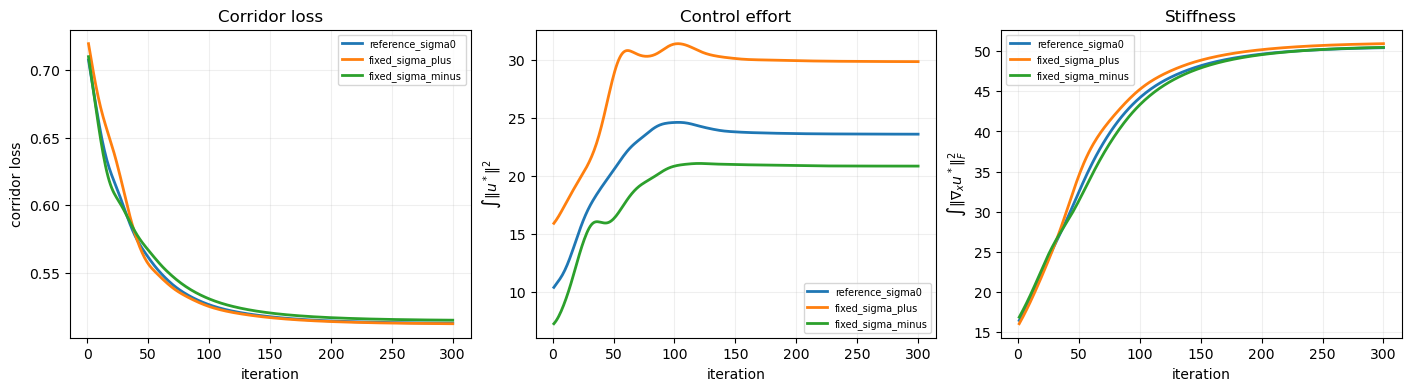

In [20]:

fig0, axes0 = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
for label, color in [("reference_sigma0","C0"), ("fixed_sigma_plus","C1"), ("fixed_sigma_minus","C2")]:
    hist = case_results[label]["history"]
    axes0[0].plot([h["iter"] for h in hist], [h["Lcorr"] for h in hist], lw=2.0, label=label, color=color)
    axes0[1].plot([h["iter"] for h in hist], [h["Lcontrol"] for h in hist], lw=2.0, label=label, color=color)
    axes0[2].plot([h["iter"] for h in hist], [h["Lstiff"] for h in hist], lw=2.0, label=label, color=color)
axes0[0].set_xlabel("iteration"); axes0[0].set_ylabel("corridor loss"); axes0[0].grid(alpha=0.2); axes0[0].legend(fontsize=7); axes0[0].set_title("Corridor loss")
axes0[1].set_xlabel("iteration"); axes0[1].set_ylabel(r"$\int \|u^*\|^2$"); axes0[1].grid(alpha=0.2); axes0[1].legend(fontsize=7); axes0[1].set_title("Control effort")
axes0[2].set_xlabel("iteration"); axes0[2].set_ylabel(r"$\int \|\nabla_x u^*\|_F^2$"); axes0[2].grid(alpha=0.2); axes0[2].legend(fontsize=7); axes0[2].set_title("Stiffness")
fig0.savefig(str(Path(FIGDIR) / "E3symfixed_loss_traces.pdf"), dpi=200, bbox_inches="tight")
plt.show()

# Figure 2: Fixed $\sigma$ schedules and optimized protocol parameters



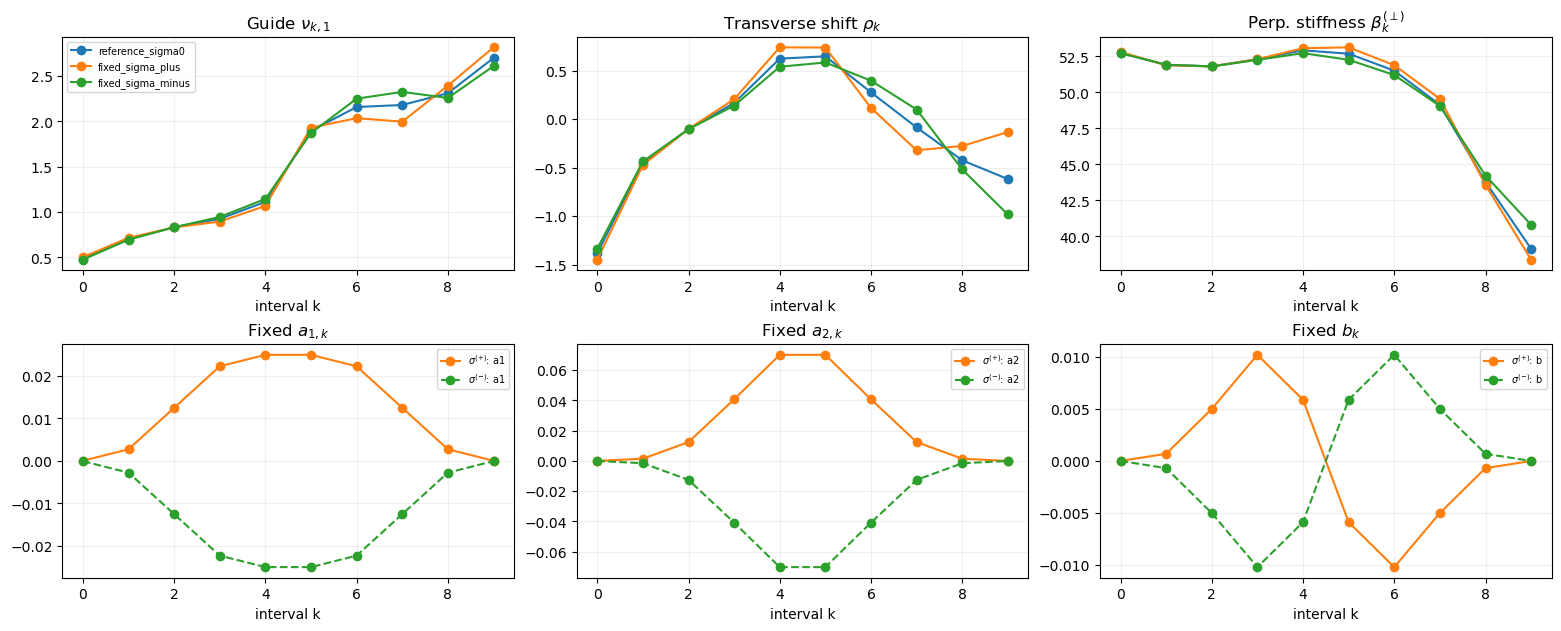

In [21]:

fig1, axes1 = plt.subplots(2, 3, figsize=(15.5, 6.2), constrained_layout=True)
axes1 = axes1.ravel()
kk = np.arange(K)

for label, color in [("reference_sigma0","C0"), ("fixed_sigma_plus","C1"), ("fixed_sigma_minus","C2")]:
    rr = case_results[label]
    axes1[0].plot(kk, rr["aux"]["nu"].detach().cpu().numpy()[:, 0], "o-", label=label, color=color)
    axes1[1].plot(kk, rr["state"].rho.detach().cpu().numpy(), "o-", label=label, color=color)
    beta_val = c_beta_to_beta_perp(rr["state"].c_beta.detach()).cpu().numpy()
    axes1[2].plot(kk, beta_val, "o-", label=label, color=color)
axes1[0].set_title(r"Guide $\nu_{k,1}$"); axes1[1].set_title(r"Transverse shift $\rho_k$"); axes1[2].set_title(r"Perp. stiffness $\beta_k^{(\perp)}$")
for ax in axes1[:3]:
    ax.set_xlabel("interval k"); ax.grid(alpha=0.2)
axes1[0].legend(fontsize=7)

for label, comp, ax in [("fixed_sigma_plus","a1",axes1[3]), ("fixed_sigma_plus","a2",axes1[4]), ("fixed_sigma_plus","b",axes1[5])]:
    pass
axes1[3].plot(kk, sigma_case_pos["a1"].detach().cpu().numpy(), "o-", label=r"$\sigma^{(+)}$: a1", color="C1")
axes1[3].plot(kk, sigma_case_neg["a1"].detach().cpu().numpy(), "o--", label=r"$\sigma^{(-)}$: a1", color="C2")
axes1[4].plot(kk, sigma_case_pos["a2"].detach().cpu().numpy(), "o-", label=r"$\sigma^{(+)}$: a2", color="C1")
axes1[4].plot(kk, sigma_case_neg["a2"].detach().cpu().numpy(), "o--", label=r"$\sigma^{(-)}$: a2", color="C2")
axes1[5].plot(kk, sigma_case_pos["b"].detach().cpu().numpy(), "o-", label=r"$\sigma^{(+)}$: b", color="C1")
axes1[5].plot(kk, sigma_case_neg["b"].detach().cpu().numpy(), "o--", label=r"$\sigma^{(-)}$: b", color="C2")
axes1[3].set_title(r"Fixed $a_{1,k}$"); axes1[4].set_title(r"Fixed $a_{2,k}$"); axes1[5].set_title(r"Fixed $b_k$")
for ax in axes1[3:]:
    ax.set_xlabel("interval k"); ax.grid(alpha=0.2); ax.legend(fontsize=7)
fig1.savefig(str(Path(FIGDIR) / "E3symfixed_protocol_params.pdf"), dpi=200, bbox_inches="tight")
plt.show()

# Run EM simulations



In [22]:

print("Running EM simulations...")
x0_sim = sample_from_marginal(
    {"weights": initial.weights, "means": initial.means, "covs": initial.covs},
    B_SIM, seed=SEED + 500,
).to(DTYPE).to(DEVICE)

em_results = {}
for idx, label in enumerate(["reference_sigma0", "fixed_sigma_plus", "fixed_sigma_minus"]):
    em_t, em_tr = simulate_distributed(
        case_results[label]["protocol"], target, x0_sim, initial, n_steps=N_STEPS_EM, seed=SEED + 600 + idx
    )
    em_results[label] = {"times": em_t, "traj": em_tr}

Running EM simulations...


# Diagnostic triplets



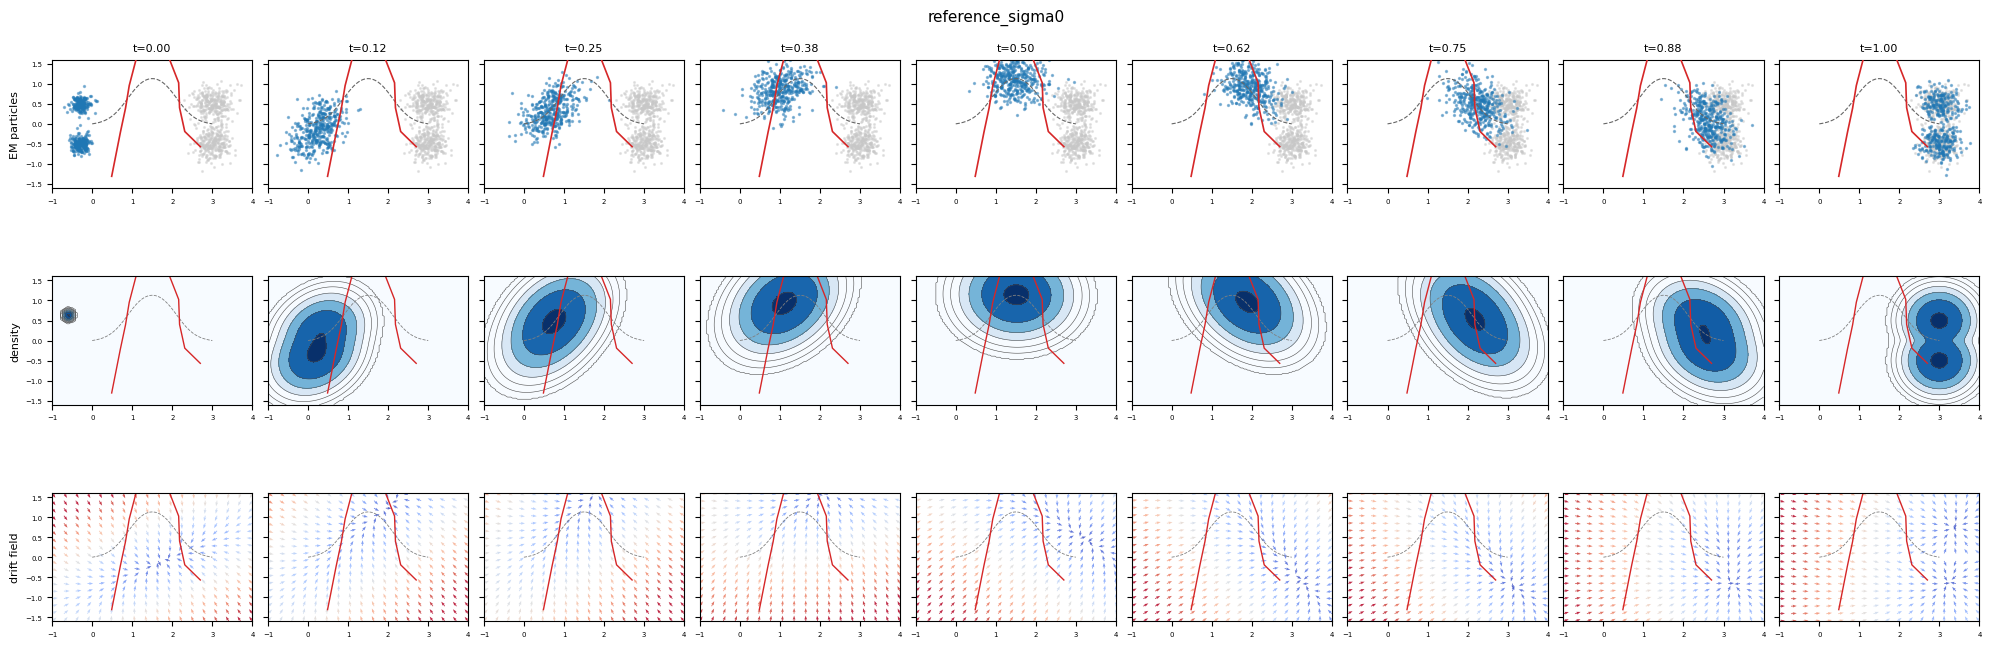

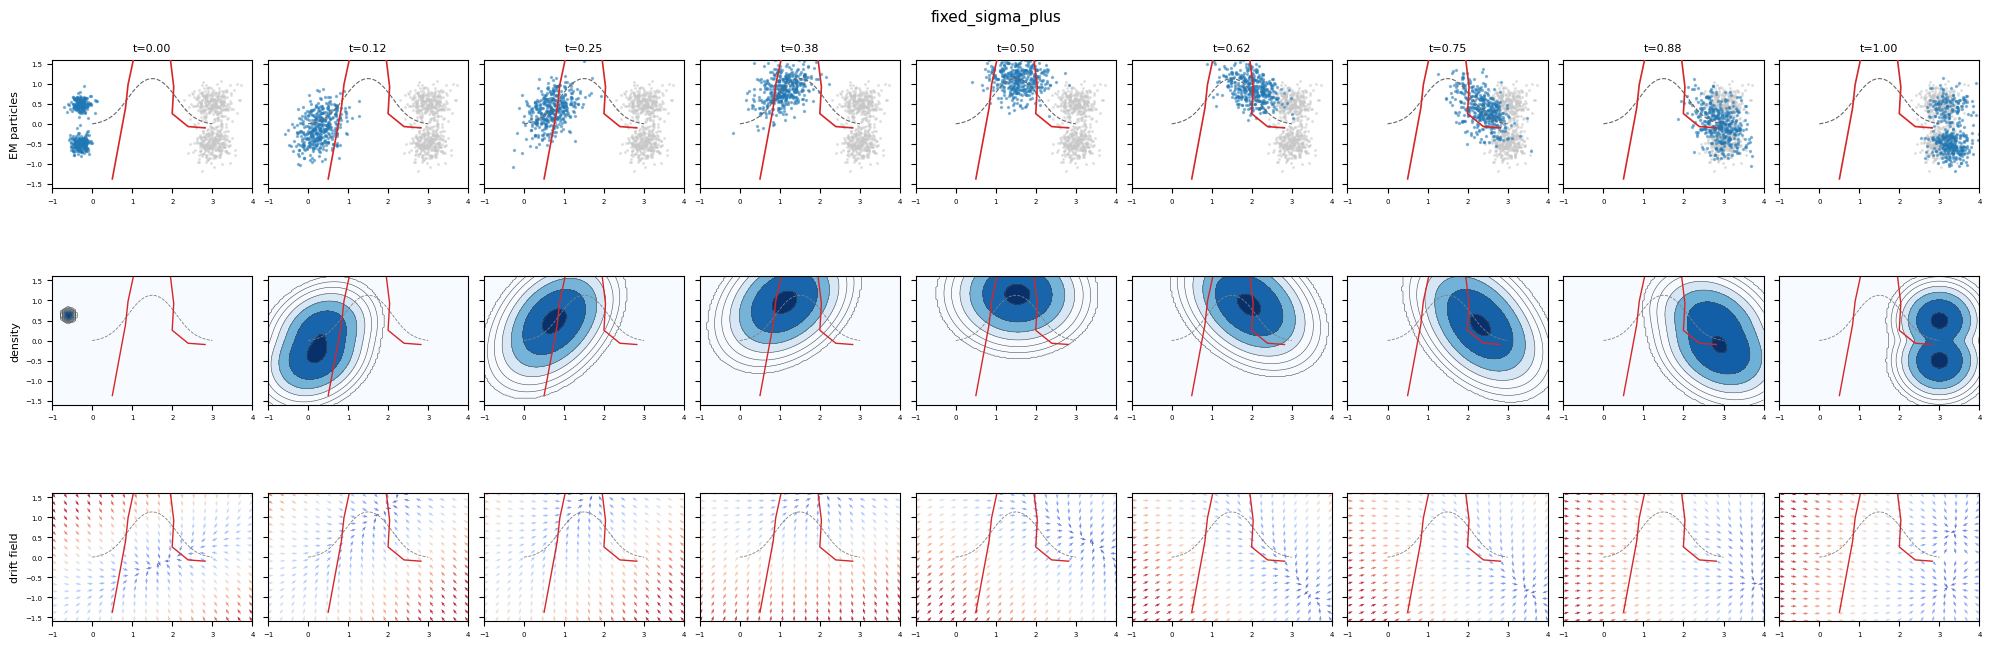

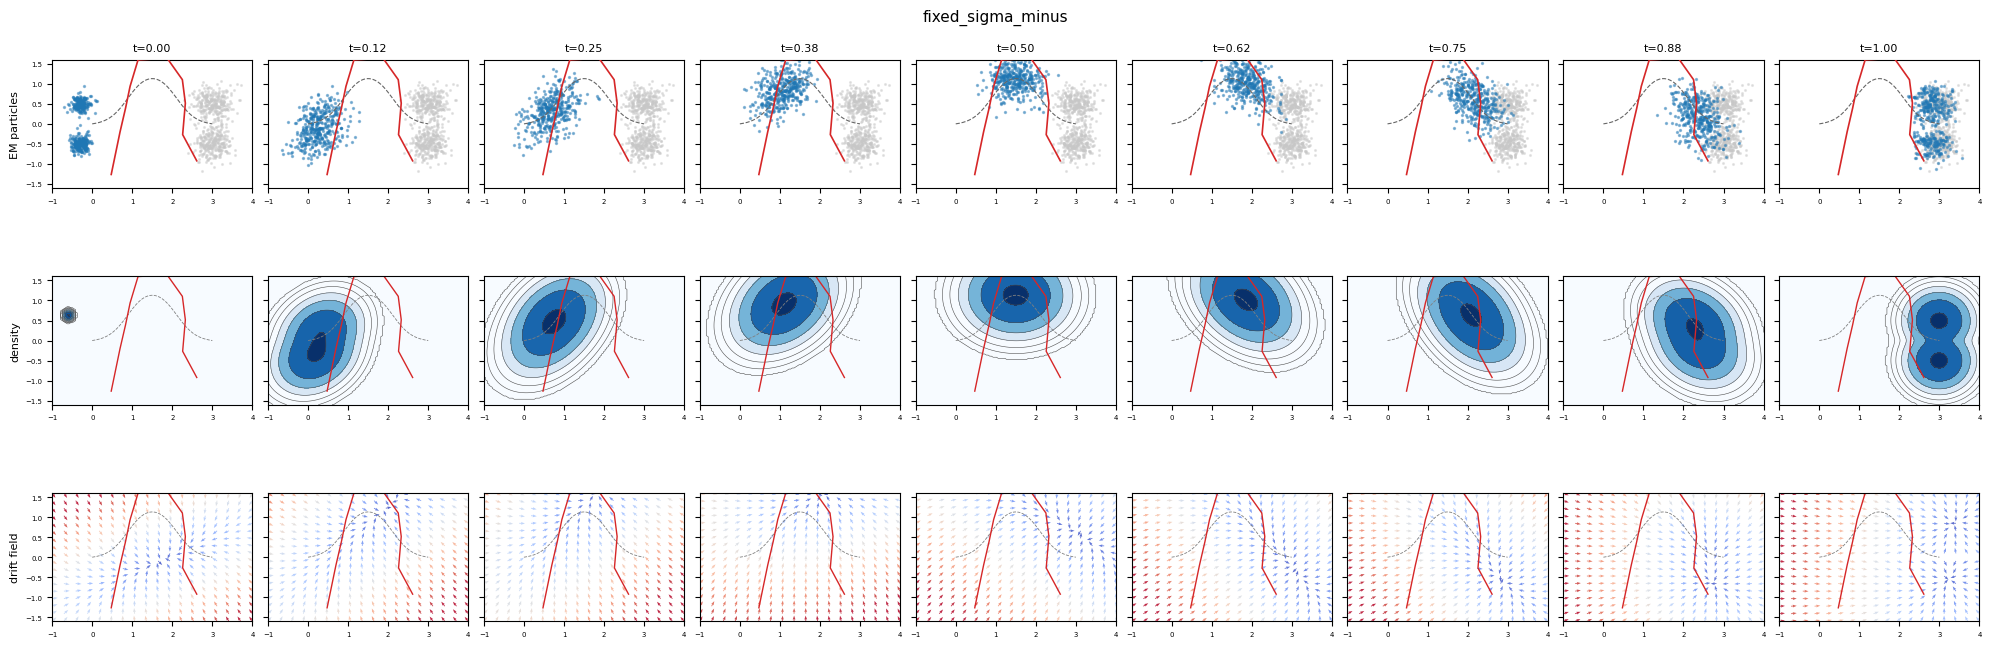

In [23]:

for label, fname in [("reference_sigma0","E3symfixed_reference_triplet.pdf"),
                     ("fixed_sigma_plus","E3symfixed_plus_triplet.pdf"),
                     ("fixed_sigma_minus","E3symfixed_minus_triplet.pdf")]:
    rr = case_results[label]
    fig = plot_diagnostic_triplet(
        rr["protocol"], target, x0_samples, SNAPSHOT_TIMES,
        corridor_xy=corridor["xy"], guide_nu=rr["aux"]["nu"],
        guide_tangent=rr["aux"]["tangent"], guide_normal=rr["aux"]["normal"],
        target_gmm=target, initial_gmm=initial,
        em_traj=em_results[label]["traj"], em_times=em_results[label]["times"],
        title_prefix=label,
    )
    fig.savefig(str(Path(FIGDIR) / fname), dpi=200, bbox_inches="tight")
    plt.show()

# Summary metrics



In [24]:

def gmm_mean_cov(marg):
    w = marg["weights"].detach()
    m = marg["means"].detach()
    c = marg["covs"].detach()
    mu = (w.unsqueeze(-1) * m).sum(0)
    S = sum(w[k] * (c[k] + torch.outer(m[k], m[k])) for k in range(w.numel())) - torch.outer(mu, mu)
    return mu, S

mu_tgt = (target.weights.unsqueeze(-1) * target.means).sum(0)
cov_tgt = sum(target.weights[k] * (target.covs[k] + torch.outer(target.means[k], target.means[k]))
              for k in range(target.M)) - torch.outer(mu_tgt, mu_tgt)

summary = {}
for label in ["reference_sigma0", "fixed_sigma_plus", "fixed_sigma_minus"]:
    rr = case_results[label]
    marg_T = marginal_from_samples(rr["protocol"], target, x0_samples, 1.0 - TD_EPS)
    mu, cov = gmm_mean_cov(marg_T)
    em_T = em_results[label]["traj"][-1].detach().cpu().numpy()
    em_T_t = torch.tensor(em_T, dtype=DTYPE)
    tgt_m_t = target.means.detach().cpu().to(DTYPE)
    dists = torch.cdist(em_T_t, tgt_m_t)
    assignments = dists.argmin(dim=1).numpy()
    mode_counts = [int((assignments == m).sum()) for m in range(target.M)]
    w_T = marg_T["weights"].detach()
    analytic_mode_weight_sums = torch.zeros(target.M, dtype=DTYPE)
    for n in range(w_T.numel()):
        analytic_mode_weight_sums[n % target.M] += w_T[n].item()
    summary[label] = {
        "Lcorr": rr["Lcorr_final"],
        "Lcontrol": rr["Lcontrol_final"],
        "Lstiff": rr["Lstiff_final"],
        "mean_err": float((mu - mu_tgt).norm().item()),
        "cov_err": float((cov - cov_tgt).norm().item()),
        "em_mode_counts": mode_counts,
        "analytic_mode_weights": [float(x) for x in analytic_mode_weight_sums.tolist()],
    }

for label, sm in summary.items():
    print(f"\n{label}")
    for k,v in sm.items():
        print(f"  {k}: {v}")




reference_sigma0
  Lcorr: 0.5127940457026238
  Lcontrol: 23.569444899898937
  Lstiff: 50.42659551932873
  mean_err: 0.004120177082021665
  cov_err: 0.0024896298953041725
  em_mode_counts: [190, 210]
  analytic_mode_weights: [0.5002387787721767, 0.49976122122782296]

fixed_sigma_plus
  Lcorr: 0.5124028801063598
  Lcontrol: 29.81912097131021
  Lstiff: 50.92842142239033
  mean_err: 0.00019658851845518797
  cov_err: 0.0023139140255682405
  em_mode_counts: [136, 264]
  analytic_mode_weights: [0.49887001658514163, 0.5011299834148589]

fixed_sigma_minus
  Lcorr: 0.5150223525786224
  Lcontrol: 20.81961101072148
  Lstiff: 50.46917779264339
  mean_err: 0.0080959471652429
  cov_err: 0.0027140229484969745
  em_mode_counts: [236, 164]
  analytic_mode_weights: [0.5016130452472574, 0.49838695475274297]


# Save compact payload



In [25]:

payload = {
    "cases": {},
    "config": {
        "SIGMA_FIXED_SCALE": SIGMA_FIXED_SCALE,
        "A1_REF_MAX": A1_REF_MAX,
        "A2_REF_MAX": A2_REF_MAX,
        "B_REF_MAX": B_REF_MAX,
    },
}
for label in case_results:
    rr = case_results[label]
    payload["cases"][label] = {
        "Lcorr_final": rr["Lcorr_final"],
        "Lcontrol_final": rr["Lcontrol_final"],
        "Lstiff_final": rr["Lstiff_final"],
        "a1": rr["aux"]["a1"].detach().cpu().tolist(),
        "a2": rr["aux"]["a2"].detach().cpu().tolist(),
        "b": rr["aux"]["b"].detach().cpu().tolist(),
    }
save_metrics_json(str(Path(OUTDIR) / "metrics_fixed_sigma_cases.json"), payload)